# 02 · Accuracy assessment and error-adjusted areas

**Question:** How accurate are the land-cover maps, and how much vegetation was really lost?

**Mirrors script:** `python/03_accuracy_olofsson.py`.
**Inputs:** `data/validation/accuracy_labels.xlsx` (blind labels), `accuracy_key.csv` (map strata), `data/tables/strata_areas.csv`.
**Outputs:** `results/accuracy_labels_matched.csv`, `accuracy_summary.csv`, `accuracy_error_matrices.csv`.

### Why this matters
Every classified map contains errors. Counting mapped pixels gives a *biased* area, and change maps are usually the worst, because the errors of two dates add up. Good practice (Olofsson et al., 2014; Stehman, 2014) is to:

1. draw random reference points **stratified by the map**, with extra points in rare classes such as loss;
2. label them **blind** (without seeing the map) from better imagery;
3. estimate accuracies and class areas with estimators that weight each stratum by its mapped area.

### How the points were drawn and labelled
Script `gee/06_accuracy_points.js` drew 300 points inside the 628 units (water in both years excluded), stratified by the 2020→2026 change map:

| Stratum | Mapped class | Points |
|---|---|---|
| 1 | Stable vegetation | 80 |
| 2 | Vegetation loss | 100 |
| 3 | Vegetation gain | 50 |
| 4 | Stable non-vegetation | 70 |

Each point was labelled blind in ArcGIS Pro as vegetation (1) or not (0), in **2020** (Esri Wayback) and **2026** (Wayback / PlanetScope).

In [1]:
# --- Setup: find the repository folders (works from notebooks/ or the repo root) ---
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
from paths import DATA, VEC, RAS, TAB, VAL, RES, ZONES, CRS   # shared folder locations
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Repository root found:', ROOT.name)

Repository root found: lagos-calabar-s1-vegetation-loss


## 1. Join the blind labels to the answer key

The `pt_id` field was damaged in the export (e.g. 10 became 1.0), so ids cannot be trusted. The coordinates are exact, so the join is made on longitude/latitude rounded to 6 decimals (about 0.1 m).

In [2]:
import json
lab = pd.read_excel(VAL / 'accuracy_labels.xlsx')
key = pd.read_csv(VAL / 'accuracy_key.csv')
xy = key['.geo'].apply(lambda g: json.loads(g)['coordinates'])
key['lon'], key['lat'] = xy.str[0], xy.str[1]
k = lambda df: list(zip(df.lon.round(6), df.lat.round(6)))
lab['k'], key['k'] = k(lab), k(key)
d = lab.merge(key[['k', 'pt_id', 'stratum']].rename(columns={'pt_id': 'pt_id_true'}), on='k', how='inner').drop(columns='k')
d['pt_id_true'] = d.pt_id_true.astype(int)
d.to_csv(RES / 'accuracy_labels_matched.csv', index=False)
print(f'{len(d)} of {len(lab)} labels matched to the key')
d.head()

300 of 300 labels matched to the key


,pt_id,lon,lat,ref2020,ref2026,pt_id_true,stratum
0,1.0,4.360198,6.399823,1,1,1,3
1,2.0,3.458110,6.438989,0,0,2,4
2,3.0,2.814107,6.426413,1,1,3,4
3,4.0,3.870167,6.471418,1,0,4,2
4,5.0,3.534107,6.431713,1,1,5,1


## 2. Map class and reference class for each point

* **2020 map:** the point is mapped as vegetation if its stratum is *stable vegetation* or *loss* (strata 1, 2).
* **2026 map:** vegetation if *stable vegetation* or *gain* (strata 1, 3).
* **Change reference:** built from the two reference labels in the same way.

In [3]:
d['map20'] = d.stratum.isin([1, 2]).astype(int)
d['map26'] = d.stratum.isin([1, 3]).astype(int)
d['refchg'] = np.select([(d.ref2020 == 1) & (d.ref2026 == 1), (d.ref2020 == 1) & (d.ref2026 == 0),
                         (d.ref2020 == 0) & (d.ref2026 == 1)], [1, 2, 3], 4)
S = pd.read_csv(TAB / 'strata_areas.csv')
A = S.area_ha.sum(); W = dict(zip(S.stratum, S.area_ha / A))
print(f'Total mapped land in the units: {A:,.0f} ha')
S.assign(weight=S.area_ha / A, points=S.stratum.map(d.groupby('stratum').size())).round(3)

Total mapped land in the units: 91,487 ha


,stratum,name,area_ha,points,weight
0,1,stable vegetation,43423.505,80,0.475
1,2,vegetation lost,9265.697,100,0.101
2,3,vegetation gained,3865.513,50,0.042
3,4,stable non-vegetation,34932.059,70,0.382


## 3. The estimators

With strata *h* (weights $W_h$ = mapped area share, $n_h$ points each), the estimated proportion of area in map class *i* and reference class *j* is

$$\hat p_{ij} = \sum_h W_h \, \frac{n_{hij}}{n_h}.$$

* **Overall accuracy** $= \sum_i \hat p_{ii}$
* **User's accuracy** of class *i* $= \hat p_{ii} / \hat p_{i\cdot}$ (of the area *mapped* as *i*, how much really is *i*? 1 − commission error)
* **Producer's accuracy** of class *j* $= \hat p_{jj} / \hat p_{\cdot j}$ (of the area that really is *j*, how much was mapped as *j*? 1 − omission error)
* **Error-adjusted area** of class *j* $= A \cdot \hat p_{\cdot j}$

Standard errors use the stratified variance of a total and, for the ratios (user's and producer's accuracy), the stratified ratio estimator of Stehman (2014). 95% CI = 1.96 × SE.

In [4]:
def olofsson(mapcol, refcol, classes):
    P = np.zeros((len(classes), len(classes)))
    for h, g in d.groupby('stratum'):
        for i, ci in enumerate(classes):
            for j, cj in enumerate(classes):
                P[i, j] += W[h] * np.mean((g[mapcol] == ci) & (g[refcol] == cj))
    def var_total(yf):
        return sum(W[h] ** 2 * np.var(yf(g).astype(float), ddof=1) / len(g) for h, g in d.groupby('stratum'))
    def ratio(yf, xf):
        Y = sum(W[h] * yf(g).mean() for h, g in d.groupby('stratum'))
        X = sum(W[h] * xf(g).mean() for h, g in d.groupby('stratum'))
        R, v = Y / X, 0
        for h, g in d.groupby('stratum'):
            y, x = yf(g).astype(float), xf(g).astype(float)
            v += W[h] ** 2 * (np.var(y, ddof=1) + R ** 2 * np.var(x, ddof=1) - 2 * R * np.cov(y, x, ddof=1)[0, 1]) / len(g)
        return R, np.sqrt(v / X ** 2)
    OA, oa_ci = np.trace(P), 1.96 * np.sqrt(var_total(lambda g: g[mapcol] == g[refcol]))
    rows = []
    for i, c in enumerate(classes):
        ua, ua_se = ratio(lambda g: (g[mapcol] == c) & (g[refcol] == c), lambda g: g[mapcol] == c)
        pa, pa_se = ratio(lambda g: (g[mapcol] == c) & (g[refcol] == c), lambda g: g[refcol] == c)
        rows.append(dict(cls=c, users=ua, users_ci=1.96 * ua_se, producers=pa, producers_ci=1.96 * pa_se,
                         map_area_ha=A * P[i, :].sum(), adj_area_ha=A * P[:, i].sum(),
                         adj_area_ci=1.96 * A * np.sqrt(var_total(lambda g: g[refcol] == c))))
    counts = pd.crosstab(d[mapcol], d[refcol]).reindex(index=classes, columns=classes, fill_value=0)
    return OA, oa_ci, pd.DataFrame(rows), counts

## 4. Results for the three maps

In [5]:
NAMES = {'DS2020 map': {1: 'Vegetation', 0: 'Non-vegetation'}, 'DS2026 map': {1: 'Vegetation', 0: 'Non-vegetation'},
         'Change 2020-2026': {1: 'Stable vegetation', 2: 'Vegetation lost', 3: 'Vegetation gained', 4: 'Stable non-vegetation'}}
summ, mats = [], []
for name, mc, rc, cl in [('DS2020 map', 'map20', 'ref2020', [1, 0]), ('DS2026 map', 'map26', 'ref2026', [1, 0]),
                         ('Change 2020-2026', 'stratum', 'refchg', [1, 2, 3, 4])]:
    OA, oaci, t, cnt = olofsson(mc, rc, cl)
    t.insert(0, 'map', name); t['class'] = t.cls.map(NAMES[name]); t['overall'] = OA; t['overall_ci'] = oaci
    summ.append(t.drop(columns='cls'))
    c = cnt.rename(index=NAMES[name], columns=NAMES[name]); c.index.name = 'map \\ reference'
    c.insert(0, 'map', name); mats.append(c.reset_index())
    print(f'{name}: overall accuracy {100*OA:.1f}% ± {100*oaci:.1f}')
summary = pd.concat(summ); summary.to_csv(RES / 'accuracy_summary.csv', index=False)
pd.concat(mats).to_csv(RES / 'accuracy_error_matrices.csv', index=False)

show = summary.assign(**{"User's %": 100 * summary.users, '±UA': 100 * summary.users_ci,
                         "Producer's %": 100 * summary.producers, '±PA': 100 * summary.producers_ci})
show[['map', 'class', "User's %", '±UA', "Producer's %", '±PA', 'map_area_ha', 'adj_area_ha', 'adj_area_ci']].round(1)

DS2020 map: overall accuracy 83.0% ± 4.9
DS2026 map: overall accuracy 83.2% ± 4.2
Change 2020-2026: overall accuracy 73.8% ± 5.2


,map,class,User's %,±UA,Producer's %,±PA,map_area_ha,adj_area_ha,adj_area_ci
0,DS2020 map,Vegetation,87.7,5.6,83.6,5.1,52689.2,55289.5,4472.5
1,DS2020 map,Non-vegetation,76.6,8.6,82.1,6.9,38797.6,36197.2,4472.5
0,DS2026 map,Vegetation,88.9,5.5,80.6,4.6,47289.0,52165.5,3880.5
1,DS2026 map,Non-vegetation,77.1,6.6,86.6,5.8,44197.8,39321.2,3880.5
0,Change 2020-2026,Stable vegetation,86.2,7.6,78.3,4.9,43423.5,47809.4,4343.3
1,Change 2020-2026,Vegetation lost,25.0,8.5,31.0,14.3,9265.7,7480.2,3065.8
2,Change 2020-2026,Vegetation gained,8.0,7.6,7.1,7.5,3865.5,4356.2,2586.2
3,Change 2020-2026,Stable non-vegetation,78.6,9.7,86.2,5.6,34932.1,31841.1,3927.5


### Error matrices (sample counts; rows = map, columns = reference)

In [6]:
for m in mats:
    print(m['map'].iloc[0]); print(m.drop(columns='map').to_string(index=False)); print()

DS2020 map
map \ reference  Vegetation  Non-vegetation
     Vegetation         149              31
 Non-vegetation          41              79

DS2026 map
map \ reference  Vegetation  Non-vegetation
     Vegetation          98              32
 Non-vegetation          70             100

Change 2020-2026
      map \ reference  Stable vegetation  Vegetation lost  Vegetation gained  Stable non-vegetation
    Stable vegetation                 69                3                  5                      3
      Vegetation lost                 52               25                  9                     14
    Vegetation gained                 20                7                  4                     19
Stable non-vegetation                  8                6                  1                     55



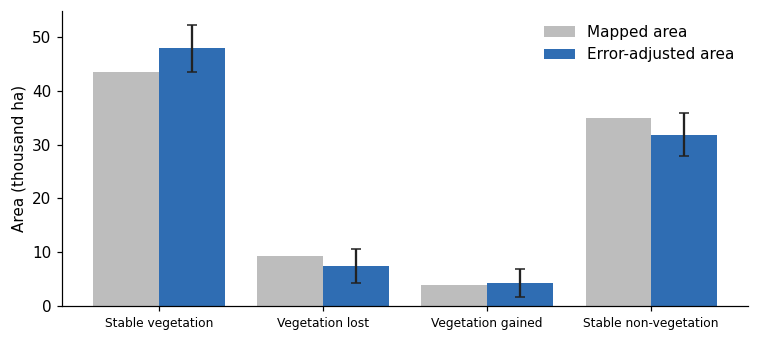

In [7]:
ch = summary[summary['map'] == 'Change 2020-2026']
fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(ch))
ax.bar(x - 0.2, ch.map_area_ha / 1000, 0.4, color='#BDBDBD', label='Mapped area')
ax.bar(x + 0.2, ch.adj_area_ha / 1000, 0.4, color='#2F6DB3', label='Error-adjusted area')
ax.errorbar(x + 0.2, ch.adj_area_ha / 1000, yerr=ch.adj_area_ci / 1000, fmt='none', ecolor='#222', capsize=3)
ax.set_xticks(x); ax.set_xticklabels(ch['class'], fontsize=8); ax.set_ylabel('Area (thousand ha)')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 5. Is the error the same in Section 1 and in the controls?

This matters for the difference-in-differences. If the loss class were **over-mapped more in Section 1** than in the controls, false loss could inflate the estimated effect. The points in the loss stratum are split by where they fall.

In [8]:
import geopandas as gpd
pts = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(d.lon, d.lat), crs=4326).to_crs(32631)
units = gpd.read_file(VEC / 'segment_zones_all.shp')[['treated', 'geometry']]
pts = gpd.sjoin(pts, units, how='left', predicate='within')
loss = pts[pts.stratum == 2]
loss.groupby('treated').apply(lambda x: pd.Series({'loss points': len(x),
        'commission error %': round(100 * (x.refchg != 2).mean(), 1)})).rename(index={0: 'Controls', 1: 'Section 1'})

,loss points,commission error %
treated,,
Controls,63.0,81.0
Section 1,37.0,64.9


## Interpretation

* The **single-date maps are 83% accurate**, and vegetation itself is mapped well (user's accuracy 88–89%, producer's 81–84%).
* The **change map is much weaker for loss**: only 25% of the area mapped as *vegetation lost* really lost its vegetation; most of the rest was vegetated in both years (seasonal or shadow differences). The error-adjusted loss is **7,480 ± 3,066 ha**, against 9,266 ha mapped.
* The false loss is **more common in the controls (81%) than in Section 1 (65%)**. Because the analysis compares Section 1 *minus* controls, this bias works *against* finding a road effect, so the estimates in notebook 03 are **conservative**.
* This is also why the hotspot analysis (notebook 05) uses *persistent* loss (non-vegetated in two consecutive years) rather than a single year's change.